# K-Nearest Neighbors (KNN) Classification Tutorial
### Machine Learning from Scratch
### Table of Contents

##### Package Installation
##### Introduction to KNN
##### Understanding the Iris Dataset
##### Data Exploration and Visualization
##### Implementing KNN Classification
##### Model Evaluation and Comparison
##### Conclusion and Key Takeaways

1. Package Installation {#installation}
First, let's install all the required packages. Run this cell first:

In [1]:
# Install required packages (run this once)
!pip install numpy pandas matplotlib seaborn scikit-learn jupyter

# If you're using conda, you can alternatively run:
# !conda install numpy pandas matplotlib seaborn scikit-learn -y


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

## 2. Introduction to K-Nearest Neighbors (KNN)
What is KNN?

K-Nearest Neighbors (KNN) is a supervised machine learning algorithm used for both classification and regression tasks. It's one of the simplest and most intuitive algorithms in machine learning.
How KNN Works:

- Choose the number K (number of neighbors to consider)
- Calculate distance between the new point and all training points
- Find the K closest neighbors to the new point
- Make prediction based on the majority class among these K neighbors

Key Characteristics:
- Lazy Learning: KNN doesn't build a model during training; it stores all training data
- Non-parametric: Makes no assumptions about data distribution
- Distance-based: Uses distance metrics (usually Euclidean distance)
- Simple but effective: Easy to understand and implement

Choosing K:
- Small K (K=1): More sensitive to noise, overfitting
- Large K: Smoother decision boundaries, might underfit
- Rule of thumb: Start with K = √(number of samples)

In [3]:
# Display images of the three Iris species
from IPython.display import Image, display, HTML
import requests
from io import BytesIO

# URLs for Iris flower images (using reliable botanical sources)
iris_images = {
    'Iris Setosa': 'https://upload.wikimedia.org/wikipedia/commons/5/56/Kosaciec_szczecinkowaty_Iris_setosa.jpg',
    'Iris Versicolor': 'https://upload.wikimedia.org/wikipedia/commons/4/41/Iris_versicolor_3.jpg',
    'Iris Virginica': 'https://upload.wikimedia.org/wikipedia/commons/9/9f/Iris_virginica.jpg'
}

# Create HTML to display images side by side
html_content = """
<div style="display: flex; justify-content: space-around; align-items: center; margin: 20px 0;">
"""

for species, url in iris_images.items():
    html_content += f"""
    <div style="text-align: center; margin: 10px;">
        <h3 style="color: #2E86AB; margin-bottom: 10px;">{species}</h3>
        <img src="{url}" alt="{species}" style="width: 250px; height: 200px; object-fit: cover; border-radius: 10px; box-shadow: 0 4px 8px rgba(0,0,0,0.3);">
    </div>
    """

html_content += "</div>"

# Display the images
display(HTML(html_content))

# Alternative method if the above doesn't work in your environment:
print("If images don't display above, you can view them at these URLs:")
for species, url in iris_images.items():
    print(f"{species}: {url}")

If images don't display above, you can view them at these URLs:
Iris Setosa: https://upload.wikimedia.org/wikipedia/commons/5/56/Kosaciec_szczecinkowaty_Iris_setosa.jpg
Iris Versicolor: https://upload.wikimedia.org/wikipedia/commons/4/41/Iris_versicolor_3.jpg
Iris Virginica: https://upload.wikimedia.org/wikipedia/commons/9/9f/Iris_virginica.jpg


## 3. Understanding the Iris Dataset
The Iris dataset is one of the most famous datasets in machine learning, introduced by Ronald Fisher in 1936.
Dataset Details:

- 150 samples of iris flowers
- 3 species: Setosa, Versicolor, Virginica (50 samples each)
- 4 features: Sepal length, sepal width, petal length, petal width

Measurements: All in centimeters

In [4]:
# Load the Iris dataset
iris = datasets.load_iris()
print("Dataset Description:")
print(iris.DESCR[:860] + "...")
#print(iris.DESCR)

Dataset Description:
.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
======...


In [5]:
# Create a pandas DataFrame for easier manipulation
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.tail())

Dataset Shape: (150, 6)

First 5 rows:
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1               1.8   

     species species_name  
145        2    virginica  
146        2    virginica  
147        2    virginica  
148        2    virginica  
149        2    virginica  


In [6]:
# Dataset statistics
print("Dataset Info:")
print(df.info())
print("\nDataset Statistics:")
print(df.describe())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
 5   species_name       150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB
None

Dataset Statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3

In [7]:
# Check for missing values and class distribution
print("Missing Values:")
print(df.isnull().sum())
print("\nClass Distribution:")
print(df['species_name'].value_counts())

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64

Class Distribution:
species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## 4. Data Exploration and Visualization
Understanding your data is crucial before building any machine learning model. Let's explore the Iris dataset visually.

<Figure size 1500x1200 with 0 Axes>

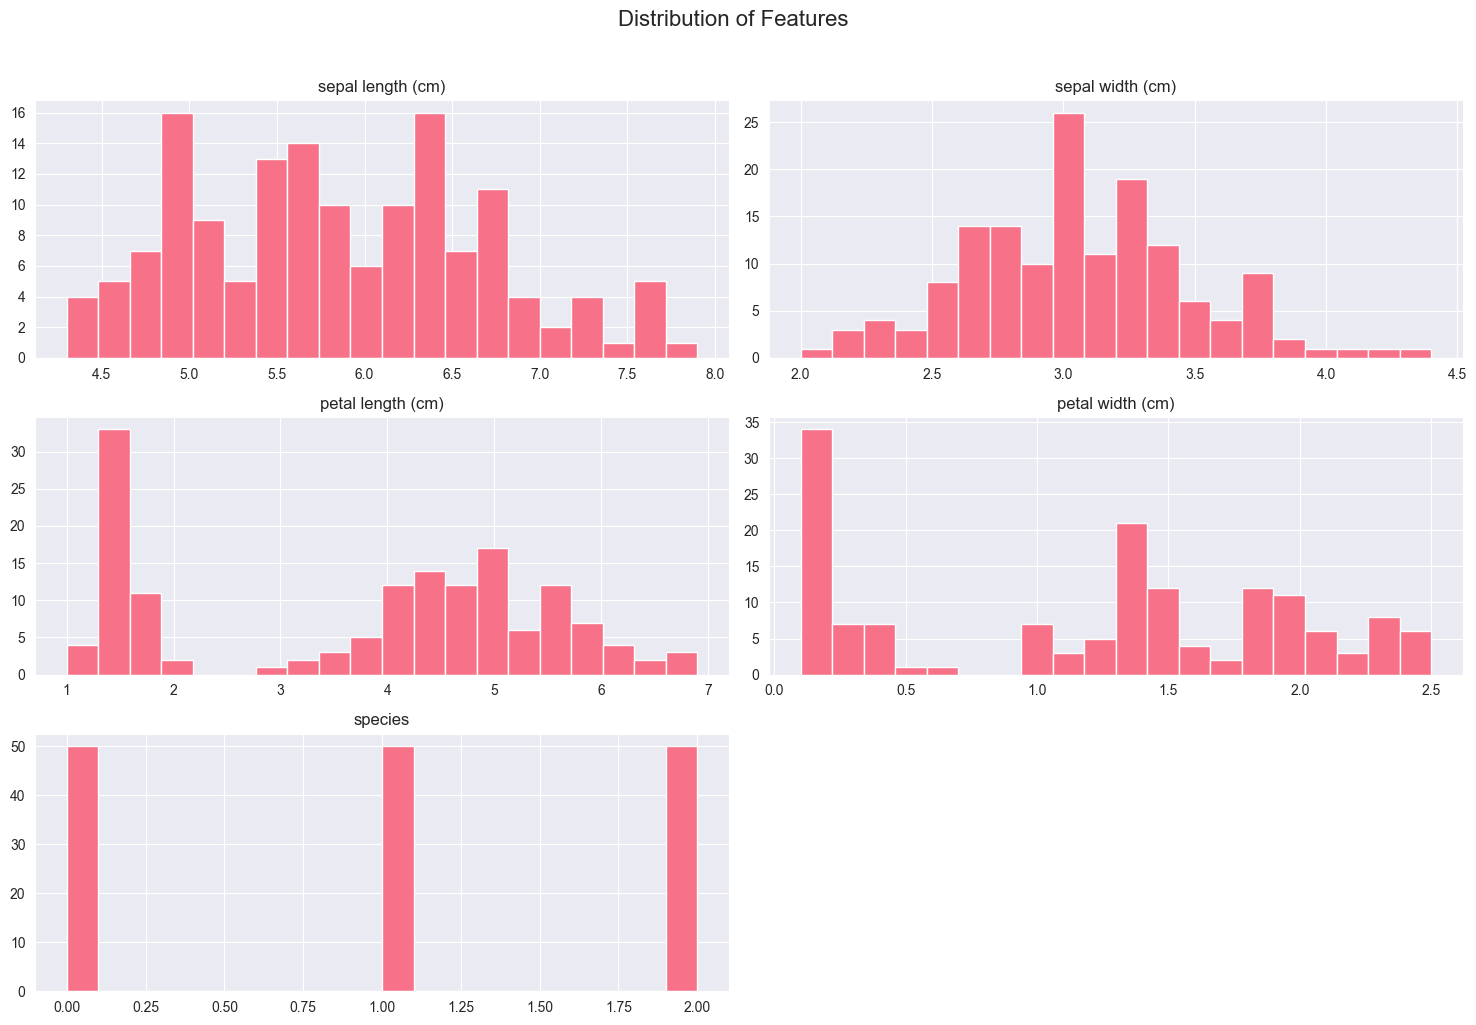

In [8]:
# Set up the plotting environment
plt.figure(figsize=(15, 12))

# 1. Distribution of each feature
#plt.subplot(2, 3, 1)
df.hist(bins=20, figsize=(15, 10))
plt.suptitle('Distribution of Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

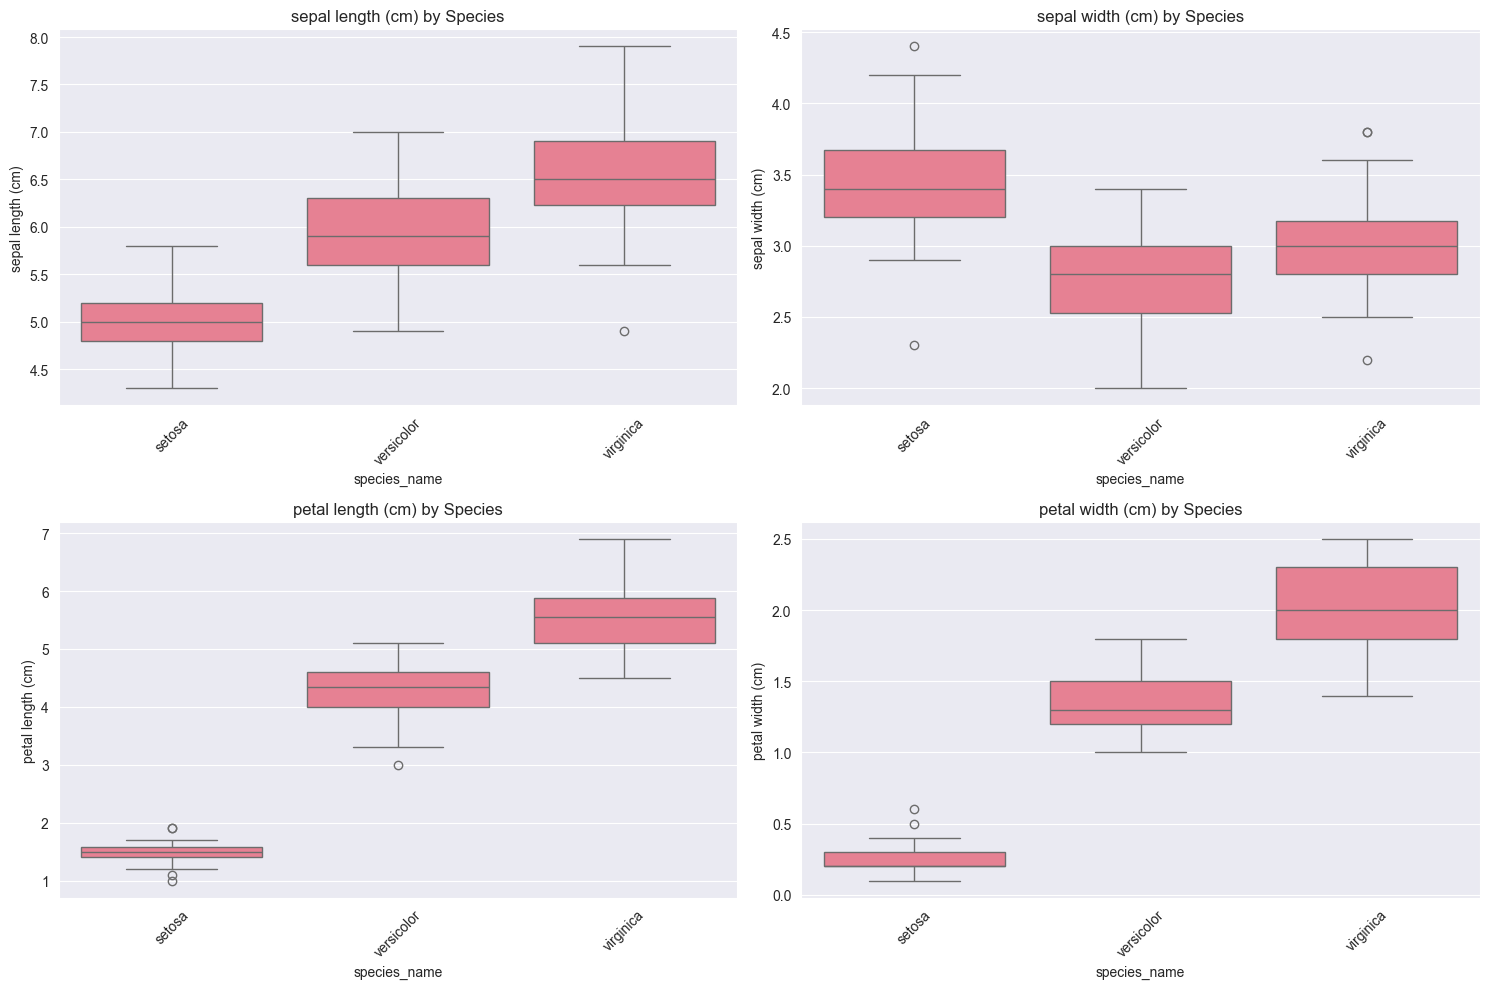

In [9]:
# 2. Box plots for each feature by species
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
features = iris.feature_names

for i, feature in enumerate(features):
    row = i // 2
    col = i % 2
    sns.boxplot(data=df, x='species_name', y=feature, ax=axes[row, col])
    axes[row, col].set_title(f'{feature} by Species')
    axes[row, col].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

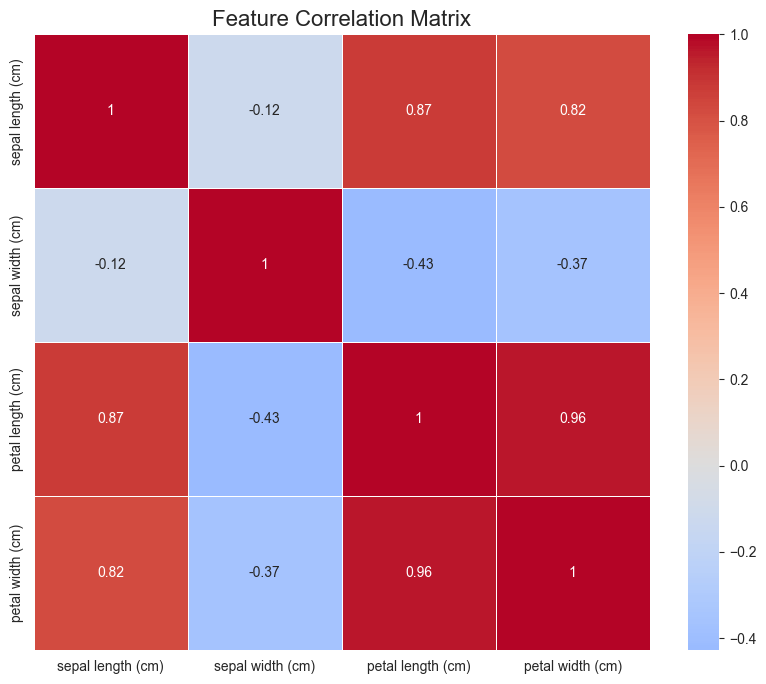

In [10]:
# 3. Correlation matrix
plt.figure(figsize=(10, 8))
correlation_matrix = df[iris.feature_names].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=16)
plt.show()

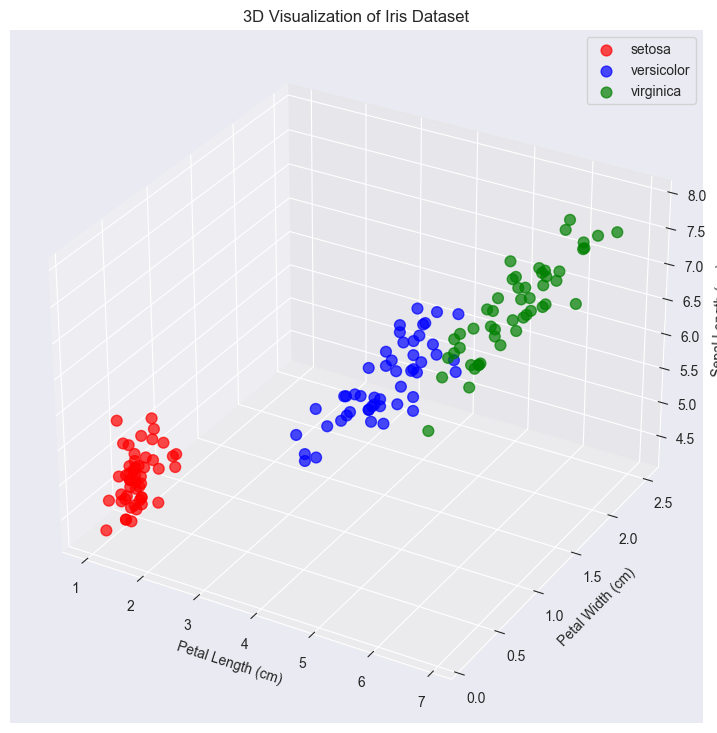

In [11]:
# 5. 3D visualization of the most important features
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Use petal length, petal width, and sepal length
colors = ['red', 'blue', 'green']
species_names = ['setosa', 'versicolor', 'virginica']

for i, (color, species) in enumerate(zip(colors, species_names)):
    mask = df['species'] == i
    ax.scatter(df[mask]['petal length (cm)'], 
               df[mask]['petal width (cm)'], 
               df[mask]['sepal length (cm)'],
               c=color, label=species, s=60, alpha=0.7)

ax.set_xlabel('Petal Length (cm)')
ax.set_ylabel('Petal Width (cm)')
ax.set_zlabel('Sepal Length (cm)')
ax.set_title('3D Visualization of Iris Dataset')
ax.legend()
plt.show()

# Key Observations from Visualization:

- Setosa is clearly separable from the other two species
- Petal measurements are more discriminative than sepal measurements
- Versicolor and Virginica have some overlap, making them harder to classify
- Strong correlation between petal length and petal width

# 5. Implementing KNN Classification 
Now let's implement KNN classification step by step.

In [12]:
# Prepare the data
X = iris.data  # Features
y = iris.target  # Target labels

print("Feature names:", iris.feature_names)
print("Target names:", iris.target_names)
print("Data shape:", X.shape)
print("Target shape:", y.shape)

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
Data shape: (150, 4)
Target shape: (150,)


### Step 1: Split the Data

In [13]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(  X, y, test_size=0.3, random_state=42, stratify=y )

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])
print("Training class distribution:", np.bincount(y_train))
print("Testing class distribution:", np.bincount(y_test))

Training set size: 105
Testing set size: 45
Training class distribution: [35 35 35]
Testing class distribution: [15 15 15]


In [14]:
y_test

array([2, 1, 2, 1, 2, 2, 1, 1, 0, 2, 0, 0, 2, 2, 0, 2, 1, 0, 0, 0, 1, 0,
       1, 2, 2, 1, 1, 1, 1, 0, 2, 2, 1, 0, 2, 0, 0, 0, 0, 1, 1, 0, 2, 2,
       1])

### Step 2: Train KNN with Different K Values

In [15]:
# Test different values of K
k_values = range(1, 21)
train_accuracies = []
test_accuracies = []

for k in k_values:
    # Create and train the KNN classifier
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train) #fit function is for training the model
    
    # Make predictions
    train_pred = knn.predict(X_train)
    y_pred = knn.predict(X_test)
    
    # Calculate accuracies
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, y_pred) # Comparing actual label v/s the predicted label
     
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    
    print(f"K={k:2d}: Train Accuracy = {train_acc:.3f}, Test Accuracy = {test_acc:.3f}")

K= 1: Train Accuracy = 1.000, Test Accuracy = 0.933
K= 2: Train Accuracy = 0.990, Test Accuracy = 0.911
K= 3: Train Accuracy = 0.962, Test Accuracy = 0.956
K= 4: Train Accuracy = 0.981, Test Accuracy = 0.956
K= 5: Train Accuracy = 0.971, Test Accuracy = 0.978
K= 6: Train Accuracy = 0.962, Test Accuracy = 0.956
K= 7: Train Accuracy = 0.971, Test Accuracy = 0.956
K= 8: Train Accuracy = 0.971, Test Accuracy = 0.933
K= 9: Train Accuracy = 0.971, Test Accuracy = 0.956
K=10: Train Accuracy = 0.971, Test Accuracy = 0.956
K=11: Train Accuracy = 0.971, Test Accuracy = 0.933
K=12: Train Accuracy = 0.971, Test Accuracy = 0.933
K=13: Train Accuracy = 0.981, Test Accuracy = 0.933
K=14: Train Accuracy = 0.962, Test Accuracy = 0.933
K=15: Train Accuracy = 0.981, Test Accuracy = 0.956
K=16: Train Accuracy = 0.981, Test Accuracy = 0.956
K=17: Train Accuracy = 0.981, Test Accuracy = 0.956
K=18: Train Accuracy = 0.952, Test Accuracy = 0.956
K=19: Train Accuracy = 0.971, Test Accuracy = 0.956
K=20: Train 

### Step 3: Visualize K vs Accuracy

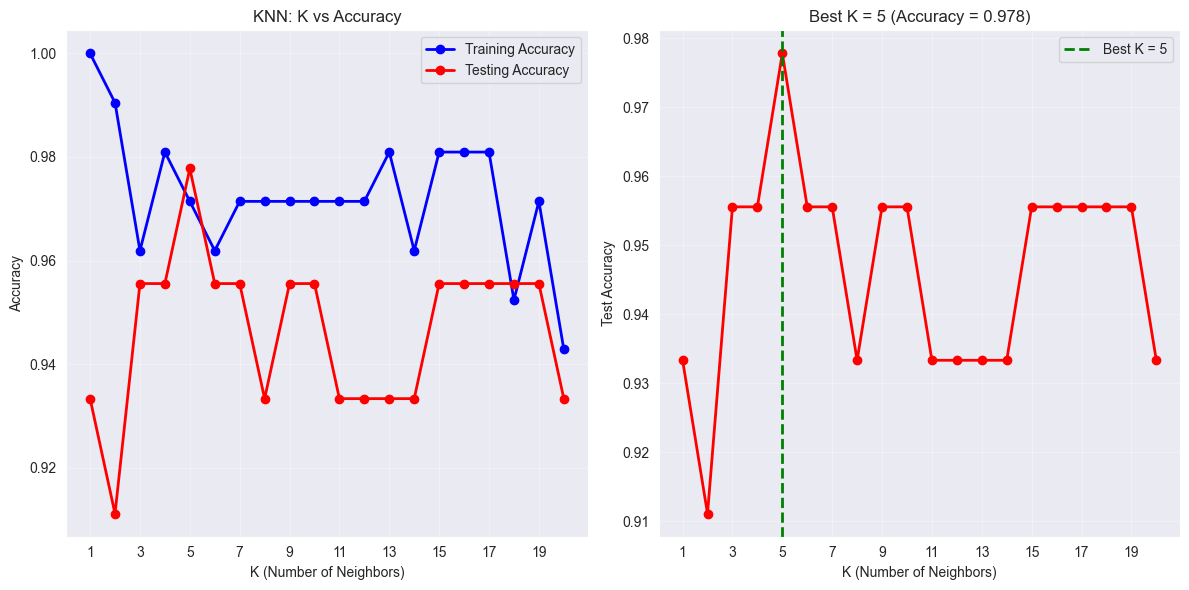


Best K value: 5
Best test accuracy: 0.978


In [16]:
# Plot K vs Accuracy
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(k_values, train_accuracies, 'bo-', label='Training Accuracy', linewidth=2)
plt.plot(k_values, test_accuracies, 'ro-', label='Testing Accuracy', linewidth=2)
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.title('KNN: K vs Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(k_values[::2])

# Find the best K
best_k = k_values[np.argmax(test_accuracies)]
best_accuracy = max(test_accuracies)

plt.subplot(1, 2, 2)
plt.plot(k_values, test_accuracies, 'ro-', linewidth=2)
plt.axvline(x=best_k, color='green', linestyle='--', linewidth=2, 
            label=f'Best K = {best_k}')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Test Accuracy')
plt.title(f'Best K = {best_k} (Accuracy = {best_accuracy:.3f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(k_values[::2])

plt.tight_layout()
plt.show()

print(f"\nBest K value: {best_k}")
print(f"Best test accuracy: {best_accuracy:.3f}")

## 6. Model Evaluation and Comparison
Let's evaluate our best model in detail.

In [17]:
# Train the final model with the best K
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train, y_train)

# Make predictions
y_pred = final_knn.predict(X_test)

print("=== Final Model Performance ===")
print(f"K = {best_k}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.3f}")

=== Final Model Performance ===
K = 5
Test Accuracy: 0.978


### Confusion Matrix

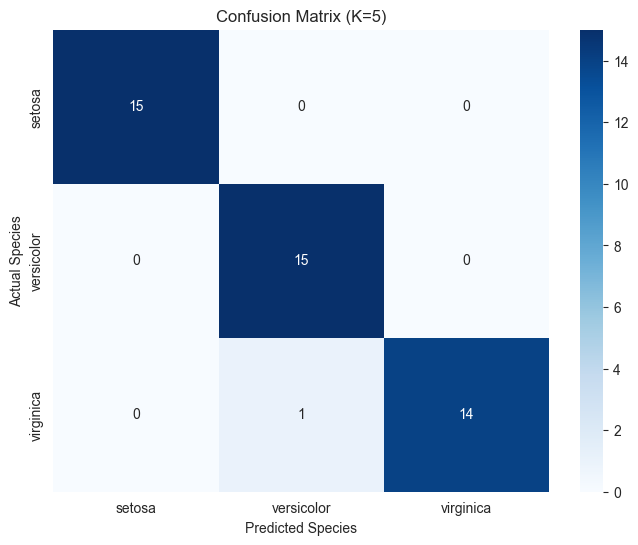


=== Detailed Classification Report ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.94      1.00      0.97        15
   virginica       1.00      0.93      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



In [18]:
# Create and visualize confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=iris.target_names, 
            yticklabels=iris.target_names)
plt.title(f'Confusion Matrix (K={best_k})')
plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')
plt.show()

# Calculate per-class metrics
print("\n=== Detailed Classification Report ===")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

In [19]:
cm

array([[15,  0,  0],
       [ 0, 15,  0],
       [ 0,  1, 14]])

## Visualizing Decision Boundaries

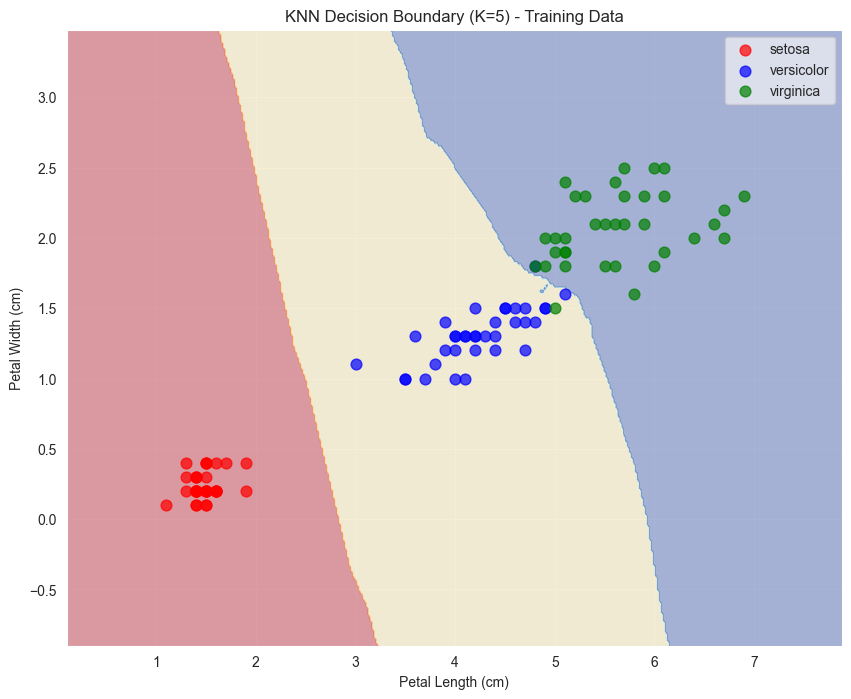

In [20]:
# Visualize decision boundaries using 2 most important features
# We'll use petal length and petal width as they're most discriminative

def plot_decision_boundary(X, y, classifier, title):
    # Create a mesh
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # Make predictions on the mesh
    mesh_points = np.c_[xx.ravel(), yy.ravel()]
    Z = classifier.predict(mesh_points)
    Z = Z.reshape(xx.shape)
    
    # Plot the decision boundary
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
    
    # Plot the data points
    colors = ['red', 'blue', 'green']
    for i, color in enumerate(colors):
        mask = y == i
        plt.scatter(X[mask, 0], X[mask, 1], c=color, 
                   label=iris.target_names[i], s=60, alpha=0.7)
    
    plt.xlabel('Petal Length (cm)')
    plt.ylabel('Petal Width (cm)')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Use only petal length and petal width for 2D visualization
X_train_2d = X_train[:, [2, 3]]  # Petal length and width
X_test_2d = X_test[:, [2, 3]]

# Train KNN with 2D data
knn_2d = KNeighborsClassifier(n_neighbors=best_k)
knn_2d.fit(X_train_2d, y_train)

# Plot decision boundary
plot_decision_boundary(X_train_2d, y_train, knn_2d, 
                      f'KNN Decision Boundary (K={best_k}) - Training Data')

## Comparing Different K Values Visually

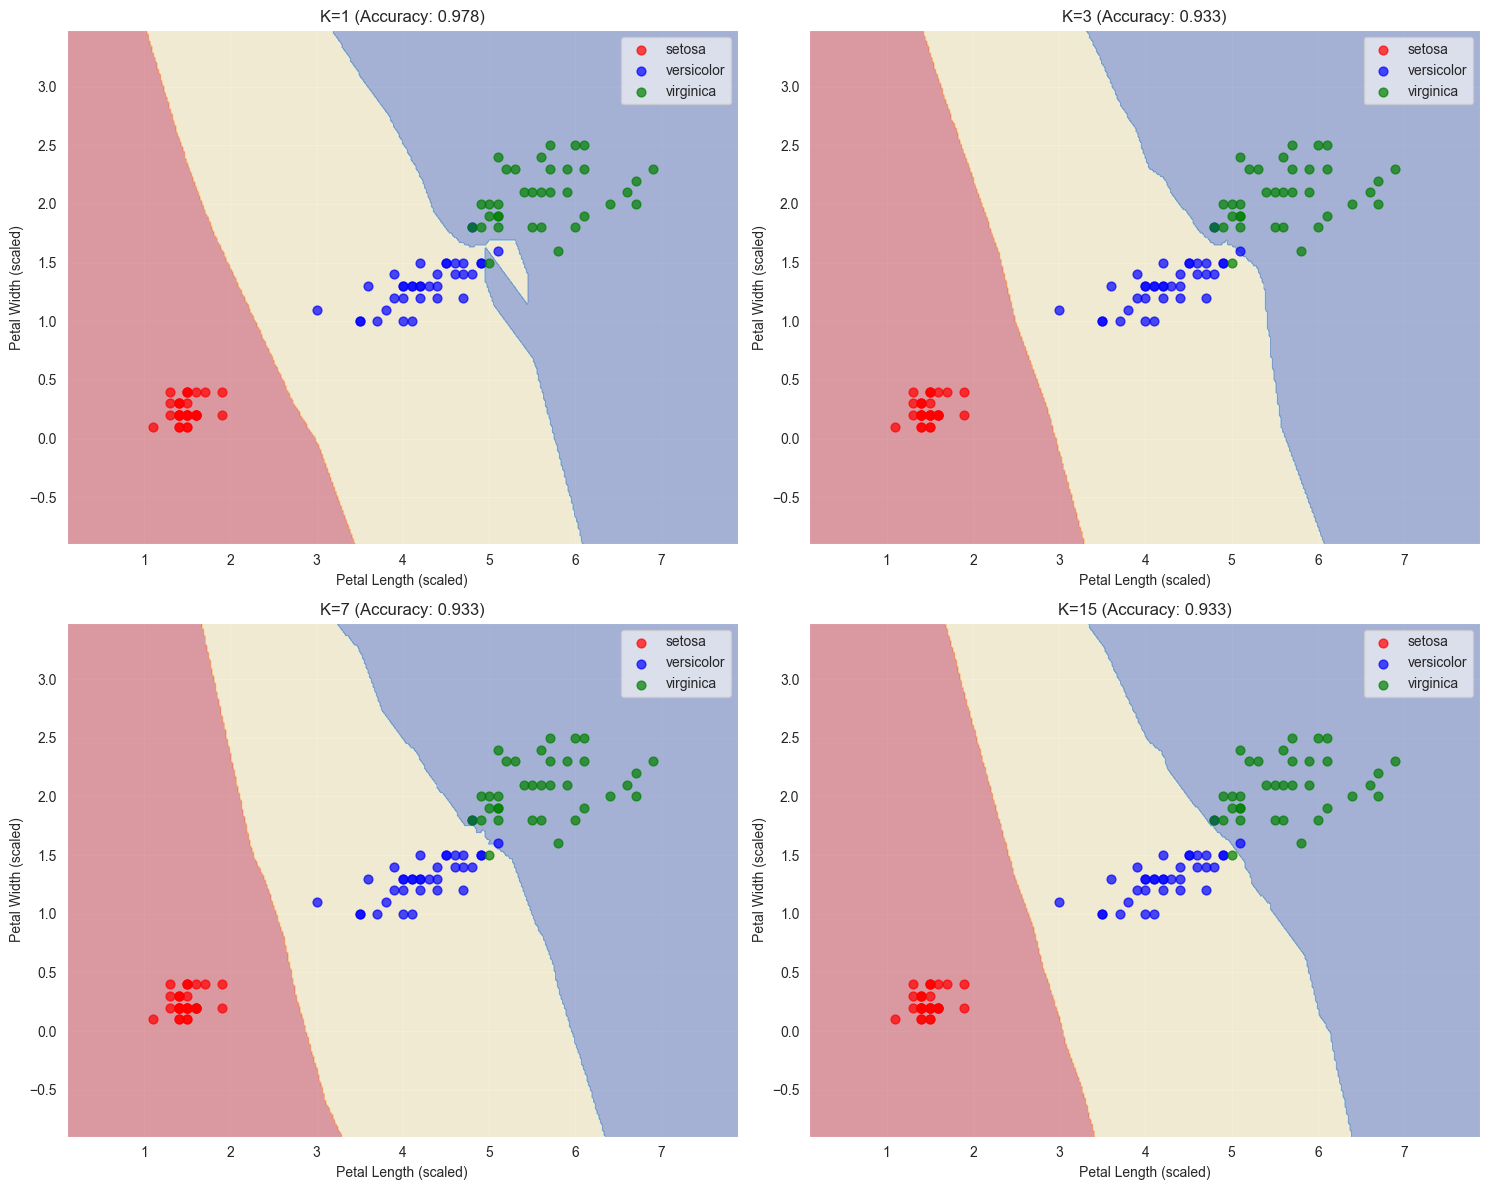

In [21]:
# Compare decision boundaries for different K values
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
k_comparison = [1, 3, 7, 15]

for i, k in enumerate(k_comparison):
    row = i // 2
    col = i % 2
    
    # Train KNN with current K
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_2d, y_train)
    
    # Create mesh for decision boundary
    h = 0.02
    x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
    y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    Z = knn_temp.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot
    axes[row, col].contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
    
    colors = ['red', 'blue', 'green']
    for j, color in enumerate(colors):
        mask = y_train == j
        axes[row, col].scatter(X_train_2d[mask, 0], X_train_2d[mask, 1], 
                              c=color, label=iris.target_names[j], s=40, alpha=0.7)
    
    # Calculate accuracy for this K
    pred_temp = knn_temp.predict(X_test_2d)
    acc_temp = accuracy_score(y_test, pred_temp)
    
    axes[row, col].set_title(f'K={k} (Accuracy: {acc_temp:.3f})')
    axes[row, col].set_xlabel('Petal Length (scaled)')
    axes[row, col].set_ylabel('Petal Width (scaled)')
    axes[row, col].legend()
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 7. Conclusion and Key Takeaways

In [22]:
print("=== FINAL RESULTS SUMMARY ===")
print(f"Best K value: {best_k}")
print(f"Final accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Number of misclassifications: {len(y_test) - np.sum(y_test == y_pred)} out of {len(y_test)}")

# Show misclassified examples
misclassified = X_test[y_test != y_pred]
if len(misclassified) > 0:
    print(f"\nMisclassified examples:")
    for i, idx in enumerate(np.where(y_test != y_pred)[0]):
        actual = iris.target_names[y_test[idx]]
        predicted = iris.target_names[y_pred[idx]]
        print(f"  Sample {idx}: Predicted {predicted}, Actually {actual}")

=== FINAL RESULTS SUMMARY ===
Best K value: 5
Final accuracy: 0.978
Number of misclassifications: 1 out of 45

Misclassified examples:
  Sample 42: Predicted versicolor, Actually virginica


## Key Takeaways
### What We Learned:

- KNN is intuitive: Easy to understand and implement
- No training phase: KNN is a lazy learning algorithm
- K selection matters: Too small → overfitting, too large → underfitting
- Feature scaling is crucial: KNN is sensitive to feature magnitudes
- Distance-based: Works well when similar instances have similar labels

### Next Steps for Further Learning

- Try different distance metrics (Manhattan, Minkowski)
- Implement KNN from scratch to understand the algorithm better
- Apply to different datasets (housing prices, breast cancer, etc.)
- Compare with other algorithms (Decision Trees, SVM, Neural Networks)
- Learn about curse of dimensionality and dimensionality reduction